In [50]:
import sys
!{sys.executable} -m pip install xgboost shap openpyxl
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import shap

In [51]:
df = pd.read_excel('Air_Quality_ML_Dataset(gurugram).xlsx')
df['date'] = pd.to_datetime(df['date'])
display(df.info(), df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   city                 720 non-null    object        
 1   state                720 non-null    object        
 2   latitude             720 non-null    float64       
 3   longitude            720 non-null    float64       
 4   date                 720 non-null    datetime64[ns]
 5   time                 720 non-null    object        
 6   month                720 non-null    int64         
 7   day_name             720 non-null    object        
 8   is_weekend           720 non-null    bool          
 9   season               720 non-null    object        
 10  time_of_day          720 non-null    object        
 11  humidity_percent     720 non-null    int64         
 12  dew_point_c          720 non-null    float64       
 13  wind_gusts_kmh       720 non-null  

None

,latitude,longitude,date,month,humidity_percent,dew_point_c,wind_gusts_kmh,precipitation_mm,pressure_msl_hpa,cloud_cover_percent,...,o3_ugm3,dust_ugm3,aod,PM2.5_si,PM210_si,CO_si,NO2_si,SO2_si,O3_si,AQI
count,7.200000e+02,7.200000e+02,720,720.0,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,...,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000,720.000000
mean,2.845950e+01,7.702660e+01,2025-09-15 12:00:00,9.0,72.529167,22.838333,21.130000,0.148889,1004.720694,34.470833,...,81.119444,173.900000,129.440278,79.712963,118.703206,28.320469,36.991493,23.790104,89.791981,160.759722
min,2.845950e+01,7.702660e+01,2025-09-01 00:00:00,9.0,33.000000,16.700000,3.200000,0.000000,996.500000,0.000000,...,0.000000,0.000000,56.000000,10.833333,6.600000,7.350000,3.000000,8.500000,0.000000,34.000000
25%,2.845950e+01,7.702660e+01,2025-09-08 00:00:00,9.0,60.000000,21.500000,14.000000,0.000000,1003.500000,0.000000,...,41.000000,7.000000,106.000000,49.666667,38.975000,16.400000,16.000000,17.000000,41.000000,90.750000
50%,2.845950e+01,7.702660e+01,2025-09-15 12:00:00,9.0,75.000000,23.400000,19.100000,0.000000,1005.050000,11.000000,...,65.000000,67.000000,132.500000,76.416667,91.850000,23.025000,29.312500,21.125000,65.000000,149.500000
75%,2.845950e+01,7.702660e+01,2025-09-23 00:00:00,9.0,85.000000,24.300000,27.700000,0.000000,1006.200000,87.250000,...,121.000000,316.500000,152.000000,95.708333,171.200000,33.487500,49.500000,29.000000,130.882353,208.000000
max,2.845950e+01,7.702660e+01,2025-09-30 00:00:00,9.0,99.000000,25.700000,49.000000,9.200000,1009.400000,100.000000,...,228.000000,714.000000,284.000000,236.000000,387.500000,104.662500,132.200000,60.125000,303.703704,388.000000
std,4.870601e-13,8.532440e-13,NaN,0.0,16.716710,1.904924,9.569422,0.722458,2.171423,40.769602,...,53.408726,206.815993,36.039374,40.602353,96.066728,18.314166,28.101407,9.743437,68.869885,84.741244


In [52]:
df['hour'] = df['time'].str.split(':').str[0].astype(int)
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
cat_cols = ['season', 'time_of_day', 'festival_period', 'crop_burning_season', 'day_name']
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
for col in ['is_weekend', 'is_raining', 'heavy_rain']:
    if col in df.columns:
        df[col] = df[col].astype(int)
drop_list = ['time', 'city', 'state', 'latitude', 'longitude', 'AQI_Category', 'aqi_category', 'pm25_category_india']
df = df.drop(columns=[c for c in drop_list if c in df.columns])

In [53]:
df = df.sort_values(['date', 'hour']).reset_index(drop=True)
y = df['AQI']
X = df.drop(columns=['AQI', 'date'])
limit = int(len(df) * 0.8)
X_train, X_test = X.iloc[:limit], X.iloc[limit:]
y_train, y_test = y.iloc[:limit], y.iloc[limit:]
dates_test = df['date'].iloc[limit:]

In [54]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42))
])
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('xgb',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=None, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [55]:
params = {
    'xgb__n_estimators': [300, 500, 700],
    'xgb__learning_rate': [0.01, 0.05],
    'xgb__max_depth': [4, 6],
    'xgb__subsample': [0.7, 0.8]
}
search = RandomizedSearchCV(pipe, params, n_iter=10, cv=TimeSeriesSplit(n_splits=3), scoring='neg_mean_absolute_error', n_jobs=-1)
search.fit(X_train, y_train)
best_model = search.best_estimator_

In [56]:
preds = best_model.predict(X_test)
metrics = pd.DataFrame({
    'MAE': [mean_absolute_error(y_test, preds)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, preds))],
    'R2': [r2_score(y_test, preds)]
})
display(metrics)

,MAE,RMSE,R2
0,3.609379,5.704656,0.994058


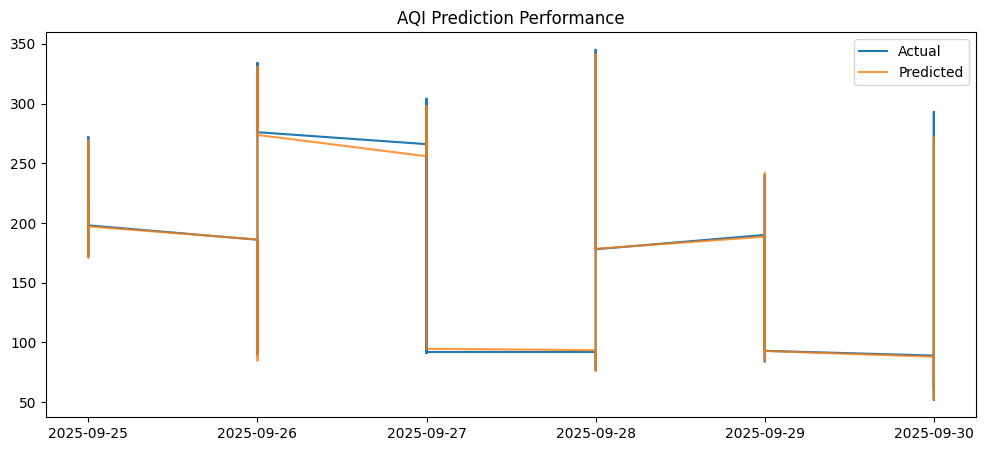

In [57]:
plt.figure(figsize=(12, 5))
plt.plot(dates_test, y_test, label='Actual')
plt.plot(dates_test, preds, label='Predicted', alpha=0.8)
plt.title('AQI Prediction Performance')
plt.legend()
plt.show()

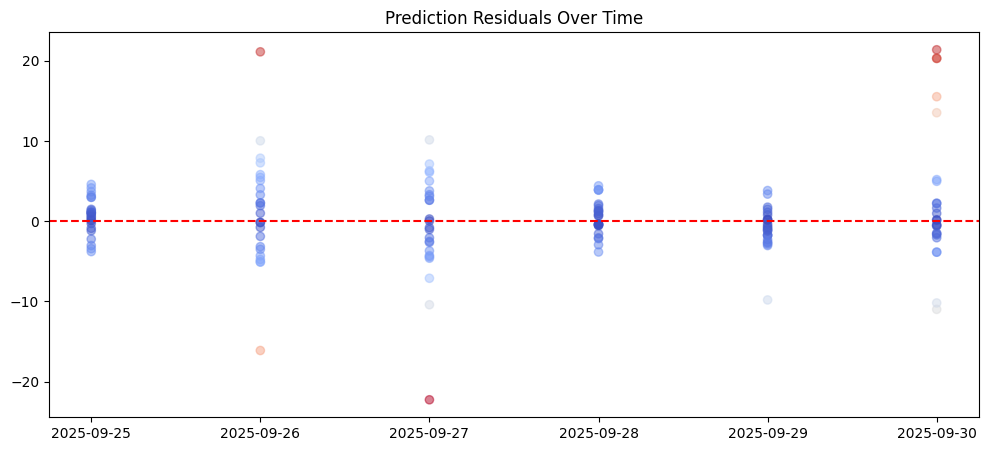

In [58]:
residuals = y_test - preds
plt.figure(figsize=(12, 5))
plt.scatter(dates_test, residuals, alpha=0.5, c=np.abs(residuals), cmap='coolwarm')
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Residuals Over Time')
plt.show()

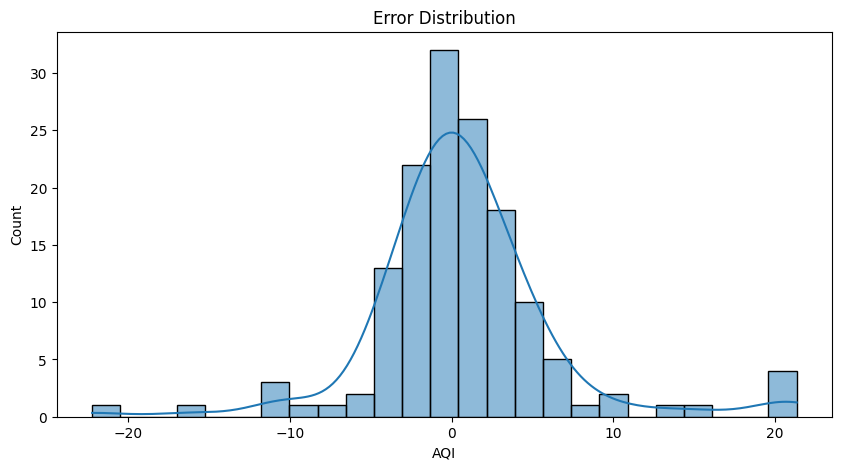

In [59]:
plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True)
plt.title('Error Distribution')
plt.show()

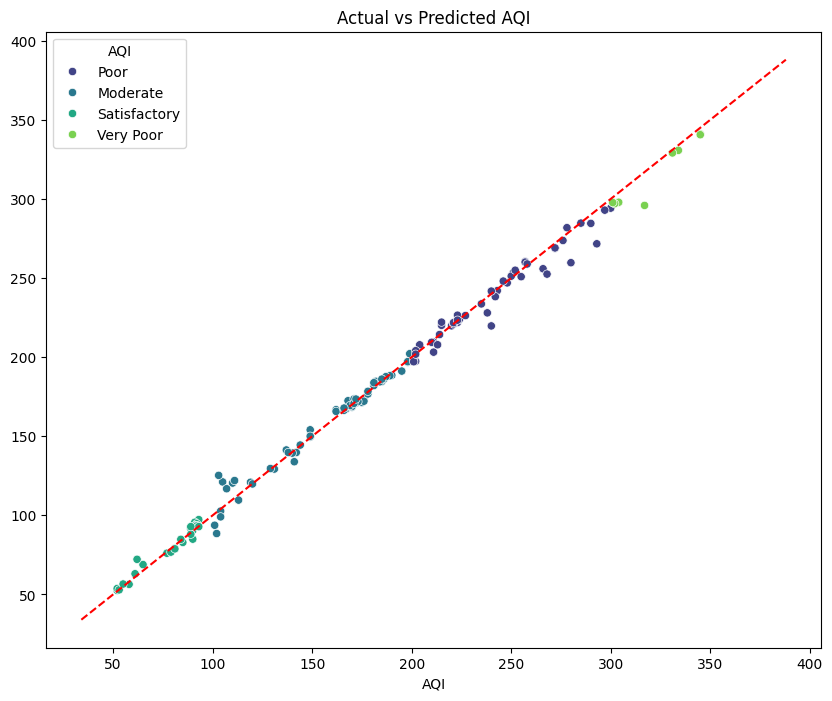

In [60]:
def get_aqi_category(aqi):
    if aqi < 50: return 'Good'
    elif aqi < 101: return 'Satisfactory'
    elif aqi < 201: return 'Moderate'
    elif aqi < 301: return 'Poor'
    elif aqi < 401: return 'Very Poor'
    else: return 'Severe'
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=preds, hue=y_test.apply(get_aqi_category), palette='viridis')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title('Actual vs Predicted AQI')
plt.show()

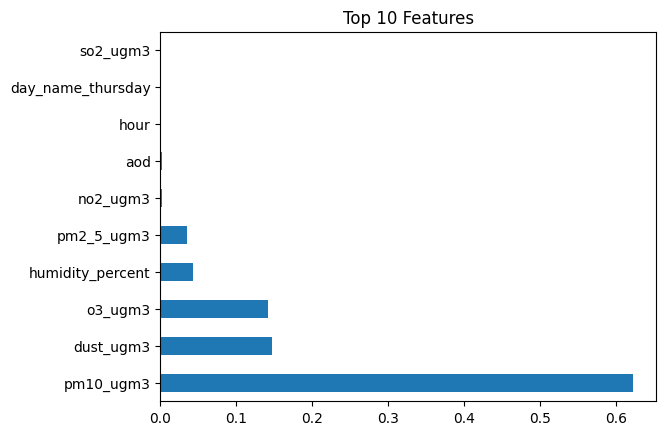

In [61]:
importances = best_model.named_steps['xgb'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', title='Top 10 Features')
plt.show()

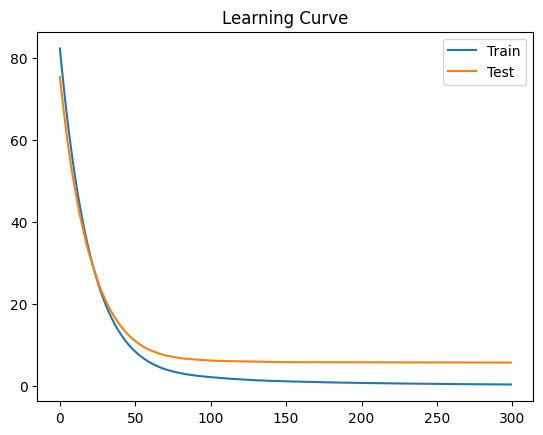

In [62]:
results = {}
scaler = best_model.named_steps['scaler']
X_tr_sc = scaler.transform(X_train)
X_te_sc = scaler.transform(X_test)
model = xgb.XGBRegressor(**best_model.named_steps['xgb'].get_params())
model.fit(X_tr_sc, y_train, eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)], verbose=False)
epochs = len(model.evals_result()['validation_0']['rmse'])
plt.plot(range(epochs), model.evals_result()['validation_0']['rmse'], label='Train')
plt.plot(range(epochs), model.evals_result()['validation_1']['rmse'], label='Test')
plt.title('Learning Curve')
plt.legend()
plt.show()

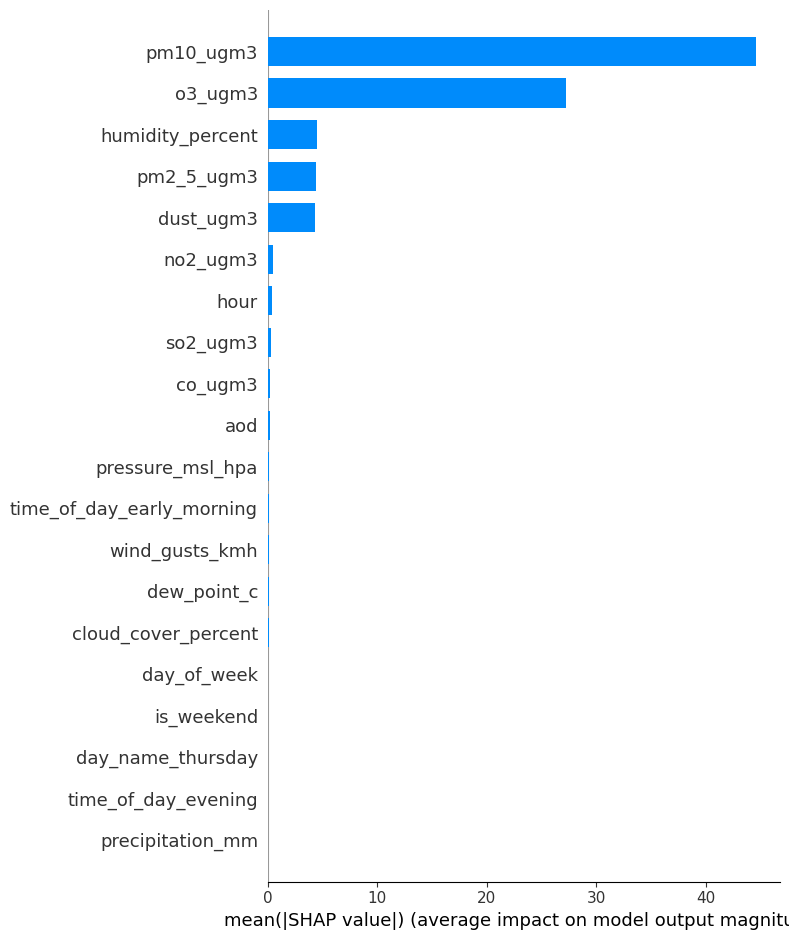

In [63]:
explainer = shap.TreeExplainer(best_model.named_steps['xgb'])
scaled_test = best_model.named_steps['scaler'].transform(X_test)
shap_values = explainer.shap_values(pd.DataFrame(scaled_test, columns=X.columns))
shap.summary_plot(shap_values, X_test, plot_type='bar')

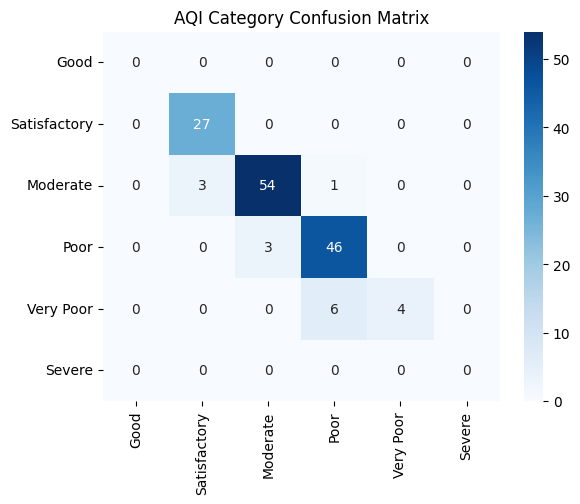

In [64]:
from sklearn.metrics import confusion_matrix
actual_cat = y_test.apply(get_aqi_category)
pred_cat = pd.Series(preds).apply(get_aqi_category)
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
cm = confusion_matrix(actual_cat, pred_cat, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.title('AQI Category Confusion Matrix')
plt.show()

In [65]:
print(f"Final Model Summary")
print(f"Test R2: {r2_score(y_test, preds):.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, preds):.2f}")
print(f"Best Params: {search.best_params_}")

Final Model Summary
Test R2: 0.9941
Test MAE: 3.61
Best Params: {'xgb__subsample': 0.7, 'xgb__n_estimators': 300, 'xgb__max_depth': 6, 'xgb__learning_rate': 0.05}
